# Definindo o problema

Neste notebook, vamos implementar e visualizar diversas funções de ativação utilizadas em Redes Neurais Profundas, como ReLU, Sigmoid, Tanh e suas variantes.

## Funções de Ativação

Vamos implementar nesse arquivo todas as funções de ativação que foram mostradas nos slides e gerar os gráficos de como é o comportamento delas. Apeans relembrando as funções são:

- ReLU
- LeakyReLU
- ELU
- SeLu
- GELU
- Swish
- Mish
- Tanh
- Sigmoid
- Softmax
- Shifted Quadratic Unit (SQU)
- Non-Monotonic Cubic (NCU)
- Shifted Sinc Unit (SSU)
- Decaying Sine Unit (DSU)
- Growing Cosine Unit (GCU)
- APALU

Obs: O gráfico das funções de ativação RReLU e PReLU são os mesmos da LeakyReLU, essas funções apenas mudam como o alpha é escolhido. RReLU de forma aleatória e PReLU é aprendida como um parâmetro da rede.

Obs2: APALU é uma função aprendida.


Material Suplementar:
- Activation Functions in Deep Learning: A Comprehensive Survey and Benchmark: https://arxiv.org/abs/2109.14545

### Importando as Bibliotecas Necessárias

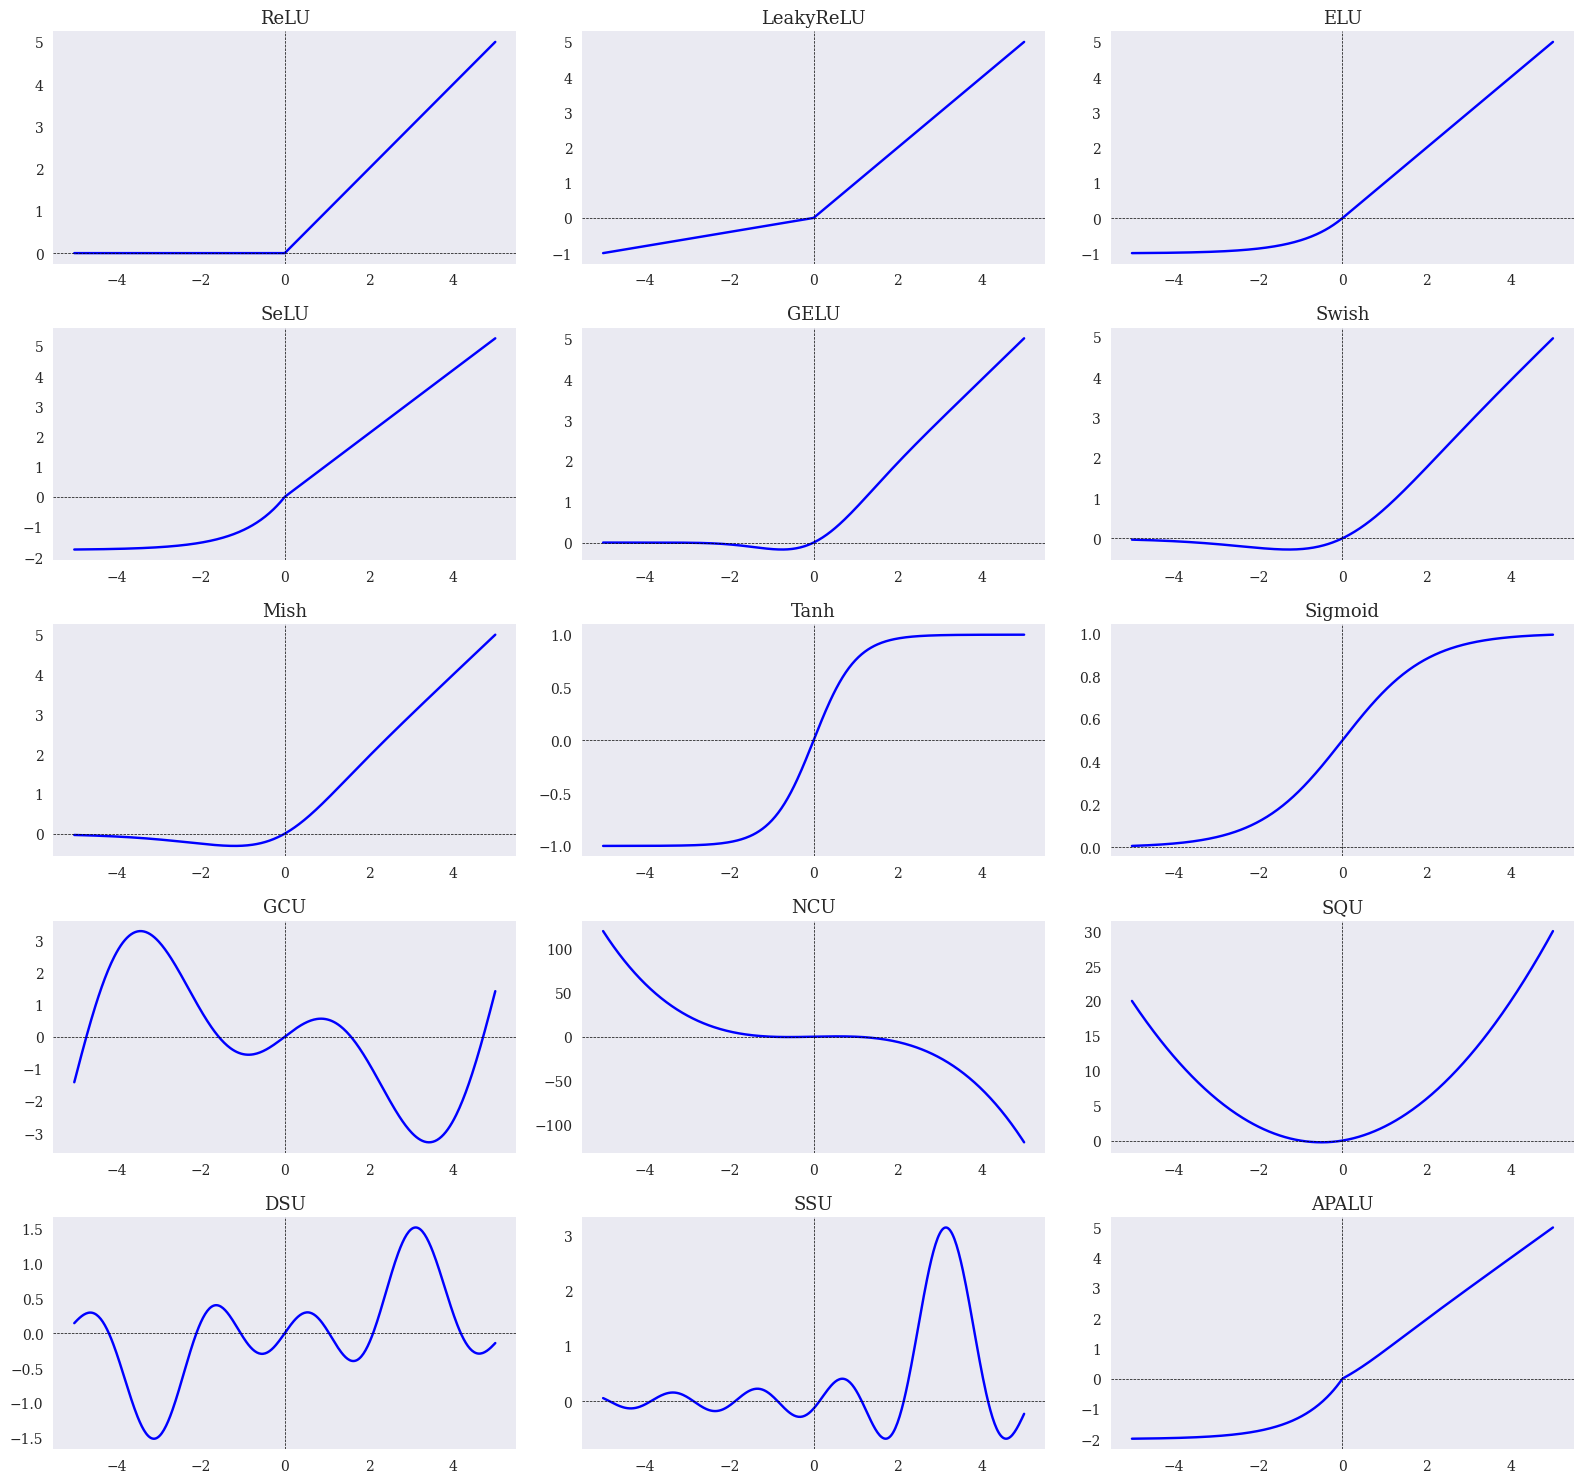

In [ ]:
import matplotlib.pyplot as plt # Principal biblioteca para criação de visualizações e gráficos em Python, essencial para analisar o comportamento do modelo e os dados.
import tensorflow as tf # Biblioteca essencial para o desenvolvimento do projeto.
import numpy as np # Biblioteca fundamental para computação científica em Python. Permite a manipulação eficiente de arrays, matrizes e a realização de diversas operações matemáticas complexas.

plt.style.use('seaborn-v0_8'),
plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "legend.fontsize": 11
})


def relu(x):
  """
  Função: relu
  Descrição: Implementa a função Rectified Linear Unit (ReLU), que zera valores negativos e mantém os positivos, ajudando a mitigar o problema do gradiente vanishing.
  """
  return np.maximum(0, x)

def leaky_relu(x, alpha=0.2):
  """
  Função: leaky_relu
  Descrição: Variante da ReLU que permite uma pequena passagem de valores negativos (gradiente pequeno), evitando que neurônios "morram" completamente durante o treino.
  """
  return np.where(x > 0, x, alpha * x)

def elu(x, alpha=1.0):
  """
  Função: elu
  Descrição: Exponential Linear Unit. Similar à ReLU, mas utiliza uma curva exponencial para valores negativos, o que pode ajudar a rede a convergir mais rápido.
  """
  return np.where(x > 0, x, alpha * (np.exp(x) - 1))

def selu(x):
  """
  Função: selu
  Descrição: Scaled Exponential Linear Unit. Uma função de ativação auto-normalizante que ajuda a manter a média e variância das ativações constantes entre camadas.
  """
  lambda_ = 1.0507
  alpha = 1.67326
  return lambda_ * elu(x, alpha)

def gelu(x):
  """
  Função: gelu
  Descrição: Gaussian Error Linear Unit. Utilizada em modelos modernos (como BERT e GPT), pesa a entrada pela sua probabilidade sob uma distribuição gaussiana.
  """
  return x * 0.5 * (1 + np.tanh(np.sqrt(2 / np.pi) * (x + 0.044715 * x**3)))

def swish(x, beta=1):
  """
  Função: swish
  Descrição: Função de ativação desenvolvida pelo Google que utiliza a fórmula x * sigmoid(beta * x), apresentando um comportamento suave e não-monotônico.
  """
  return x / (1 + np.exp(-beta*x))

def mish(x):
  """
  Função: mish
  Descrição: Uma função de ativação suave e auto-regularizada definida como x * tanh(softplus(x)). Mostra resultados superiores em diversas arquiteturas de visão.
  """
  return x * np.tanh(np.log1p(np.exp(x)))

def tanh(x):
  """
  Função: tanh
  Descrição: Função Tangente Hiperbólica. Comprime os valores de entrada no intervalo entre -1 e 1, sendo centrada em zero.
  """
  return np.tanh(x)

def sigmoid(x):
  """
  Função: sigmoid
  Descrição: Função Sigmoide. Transforma qualquer valor de entrada em uma probabilidade entre 0 e 1, muito usada na camada de saída para classificação binária.
  """
  return 1 / (1 + np.exp(-x))

def GCU(x):
  """
  Função: GCU
  Descrição: Growing Cosine Unit. Uma função de ativação baseada em cosseno que pode capturar padrões periódicos nos dados.
  """
  return x * np.cos(x)

def NCU(x):
  """
  Função: NCU
  Descrição: Non-Monotonic Cubic Unit. Utiliza uma função cúbica não-monotônica para introduzir complexidade matemática na ativação.
  """
  return x - x**3

def SQU(x):
  """
  Função: SQU
  Descrição: Shifted Quadratic Unit. Uma função quadrática deslocada que serve como uma alternativa não-linear simples para certas arquiteturas.
  """
  return x**2 + x

def DSU(x):
  """
  Função: DSU
  Descrição: Decaying Sine Unit. Uma função baseada em seno que decai conforme o valor se afasta da origem.
  """
  return (np.pi/2) * (np.sinc(x - np.pi) - np.sinc(x + np.pi))

def SSU(x):
  """
  Função: SSU
  Descrição: Shifted Sinc Unit. Baseada na função sinc (sin(x)/x), deslocada para fornecer uma resposta não-linear específica.
  """
  return np.pi * np.sinc(x - np.pi)

def APALU(x, a=0.5, b=2):
  """
  Função: APALU
  Descrição: Adaptive Piecewise Active Linear Unit. Uma função de ativação aprendível que ajusta sua forma durante o treinamento.
  """
  return np.where(x >= 0, a*(x + x*(1/(1 + np.exp(-1.702*x)))), b*(np.exp(x) - 1))

# Gerar valores para o eixo X
x = np.linspace(-5, 5, 400)

# Criar o gráfico de cada função
fig, axes = plt.subplots(5, 3, figsize=(16, 15))
functions = {
    "ReLU": relu,
    "LeakyReLU": leaky_relu,
    "ELU": elu,
    "SeLU": selu,
    "GELU": gelu,
    "Swish": swish,
    "Mish": mish,
    "Tanh": tanh,
    "Sigmoid": sigmoid,
    "GCU": GCU,
    "NCU": NCU,
    "SQU": SQU,
    "DSU": DSU,
    "SSU": SSU,
    "APALU": APALU
}

for ax, (name, func) in zip(axes.flat, functions.items()):
    y = func(x)
    ax.plot(x, y, label=name, color='b')
    ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
    ax.axvline(0, color='black', linewidth=0.5, linestyle='--')
    ax.set_title(name)
    ax.grid()

plt.tight_layout()
plt.show()

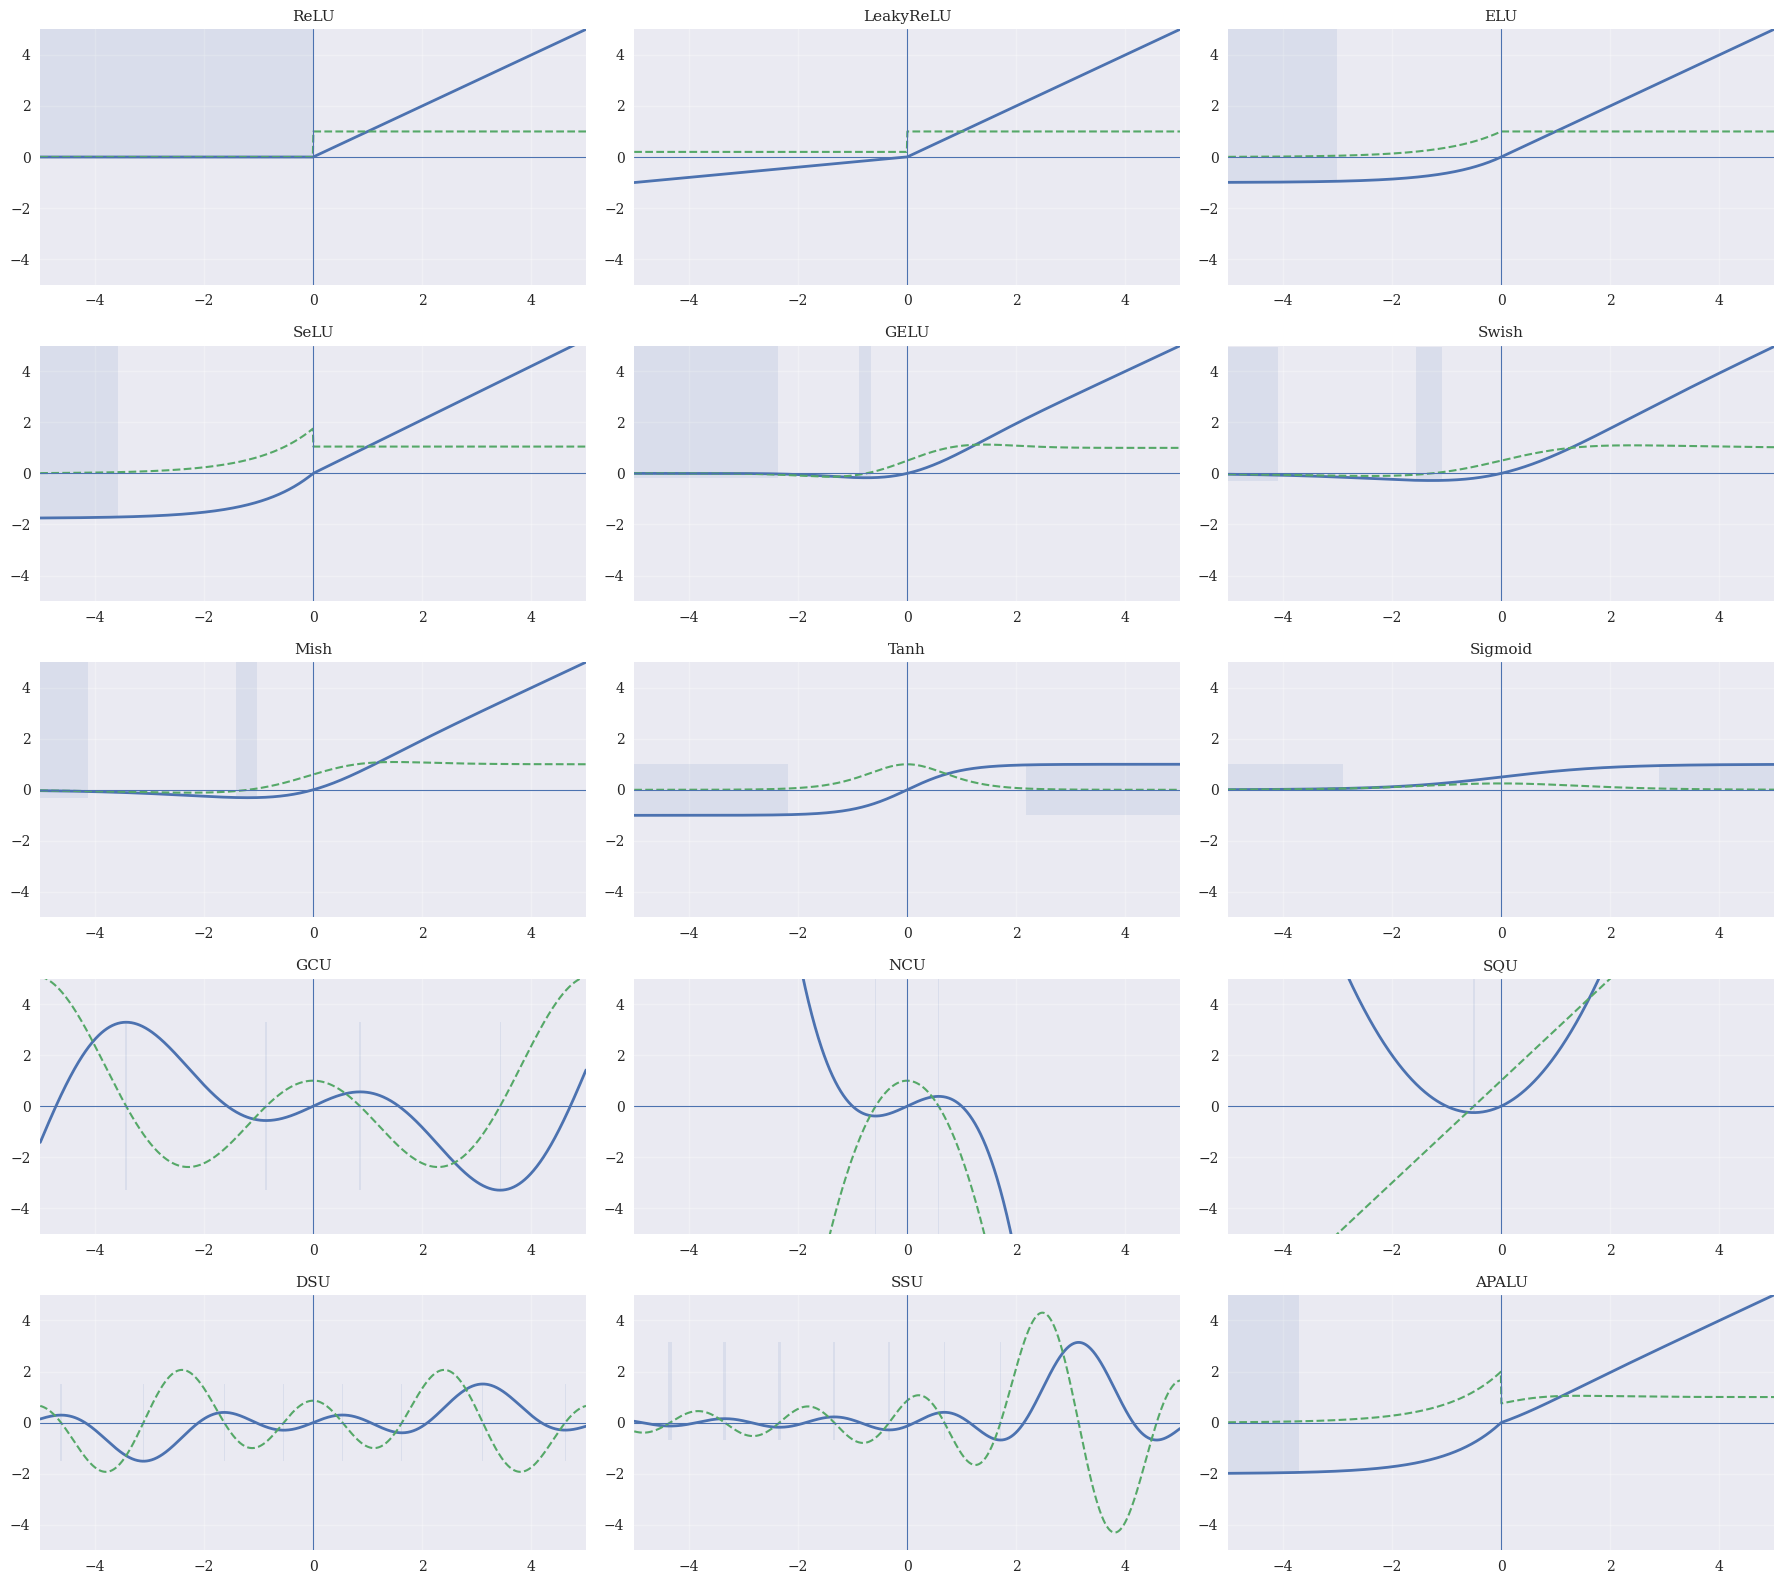

In [ ]:
def numerical_derivative(f, x, eps=1e-5):
  """
  Função: numerical_derivative
  Descrição: Calcula a derivada de uma função de forma numérica usando a técnica de diferença finita, utilizada para verificar gradientes analíticos.
  """
  return (f(x + eps) - f(x - eps)) / (2 * eps)

x = np.linspace(-5, 5, 1000)
fig, axes = plt.subplots(5, 3, figsize=(18, 16))

for ax, (name, func) in zip(axes.flat, functions.items()):
    y = func(x)
    dy = numerical_derivative(func, x)

    ax.plot(x, y, linewidth=2, label='f(x)')
    ax.plot(x, dy, linestyle='--', linewidth=1.5, label="f'(x)")
    ax.axhline(0, linewidth=0.8)
    ax.axvline(0, linewidth=0.8)
    mask = np.abs(dy) < 0.05
    ax.fill_between(x, y.min(), y.max(), where=mask, alpha=0.1)
    ax.set_title(name, fontsize=11)
    ax.set_xlim(-5, 5)
    ax.set_ylim(-5, 5)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Sigmoid - Família Sigmoid e da Tangente Hiperbólica

Logistic Sigmoid é uma das funções de ativação mais antigas da literatura, é definida pela equação:

$\hspace{5cm} Sigmoid(x) = \frac{1}{1 + e^{-x}}$

E sua derivada é calculada por:

$\hspace{5cm} \frac{dSigmoid}{dx} = sigmoid(x)(1 - sigmoid(x))$

Grande problema da Sigmoid é que ela é saturada tanto para valores positivos quanto negativos, o que leva a um problema sério de desaparecimento de gradiente. Além disso ela não é uma medida zero-centrada o que pode levar a uma convergência ruim. Além disso, ainda possui o problema da complexidade computacional por ter uma exponencial em sua função.

Características:
- Não Paramétrica
- Monotônica (piecewise linear)
- Suave
- É limitada negativamente e positivamente: $[0, 1]$

![image.png](https://figures.semanticscholar.org/d37b3c758faa8a998fd1e76be25a3dbe0c86cca2/3-Table2-1.png)



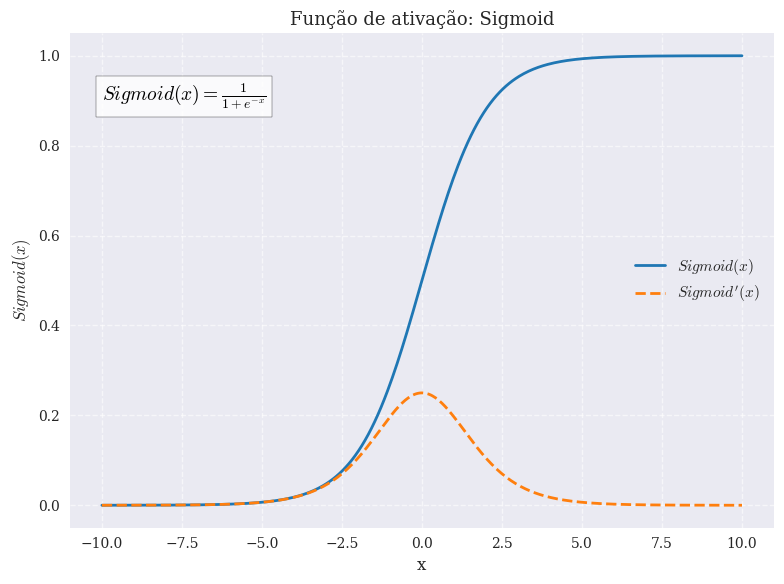

In [ ]:
def sigmoid_derivative(x):
  """
  Função: sigmoid_derivative
  Descrição: Calcula a derivada analítica da função Sigmoide, necessária para o ajuste de pesos durante o processo de retropropagação.
  """
  return sigmoid(x) * (1 - sigmoid(x))

x = np.linspace(-10, 10, 400)
y_sigmoid = sigmoid(x)
dy_sigmoid = sigmoid_derivative(x)

plt.figure(figsize=(8, 6))
plt.plot(x, y_sigmoid, label="$Sigmoid(x)$", color='#1f77b4', linewidth=2)
plt.plot(x, dy_sigmoid, label="$Sigmoid'(x)$", color='#ff7f0e', linewidth=2, linestyle='--')
plt.grid(True, linestyle='--', alpha=0.6)

plt.text(-10, 0.9, r"$Sigmoid(x) = \frac{1}{1 + e^{-x}}$", fontsize=14, color='black', bbox=dict(facecolor='white', alpha=0.8))

plt.title("Função de ativação: Sigmoid")
plt.xlabel("x")
plt.ylabel("$Sigmoid(x)$")
plt.legend()
plt.tight_layout()
plt.savefig('Sigmoid.png', bbox_inches='tight')
plt.show()

### Sigmoid - Família Sigmoid e da Tangente Hiperbólica

Tangente Hiperbólica (Tanh) junto com a Sigmoid também é uma das funções de ativação mais antigas da literatura, é definida pela equação:

$\hspace{5cm} tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$

E sua derivada é calculada por:

$\hspace{5cm} \frac{dtanh}{dx} = 1 - tanh(x)^2$

Tanh resolve a questão de ser zero-centrada da Sigmoid, mas ainda preserva os prinicapis problemas, complexidade computacional e o desaparecimento do gradiente devido ao fato de ser uma função limitada.

Características:
- Não Paramétrica
- Monotônica (piecewise linear)
- Suave
- É limitada negativamente e positivamente: $[-1, 1]$

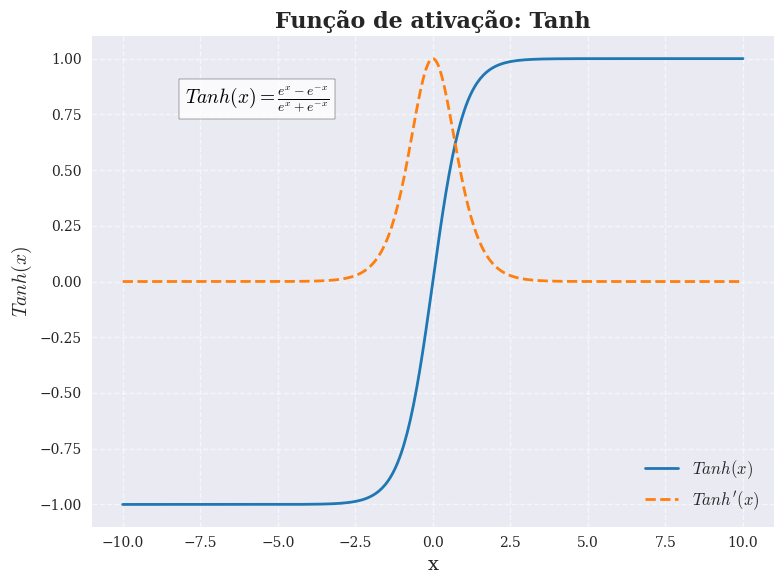

In [ ]:
def tanh_derivative(x):
  """
  Função: tanh_derivative
  Descrição: Calcula o gradiente da função Tangente Hiperbólica, indicando a taxa de variação da ativação para o backpropagation.
  """
  return 1 - np.tanh(x)**2

y_tanh = tanh(x)
dy_tanh = tanh_derivative(x)

plt.figure(figsize=(8, 6))
plt.plot(x, y_tanh, label="$Tanh(x)$", color='#1f77b4', linewidth=2)
plt.plot(x, dy_tanh, label="$Tanh'(x)$", color='#ff7f0e', linewidth=2, linestyle='--')
plt.grid(True, linestyle='--', alpha=0.6)

plt.text(-8, 0.8, r"$Tanh(x) = \frac{e^{x} - e^{-x}}{e^{x} + e^{-x}}$", fontsize=14, color='black', bbox=dict(facecolor='white', alpha=0.8))

plt.title("Função de ativação: Tanh", fontsize=16, fontweight='bold')
plt.xlabel("x", fontsize=14)
plt.ylabel("$Tanh(x)$", fontsize=14)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('Tanh.png', dpi=300)
plt.show()

### ReLU - Família ReLU

Rectified Linear Units (ReLU) é definido pela equação:

$\hspace{5cm} ReLU(x) = max(0, x)$

E sua derivada é calculada por:

$\hspace{5cm} \frac{dReLU}{dx} = \begin{cases} 1, \qquad x > 0 \\ 0, \qquad x \leq 0\end{cases}$

ReLU se tornou por bastante tempo o estado da arte das funções de ativação (principalmente pela eficiência computacional) resolveram os problemas da Sigmoid e da Tangente Hiperbólica. A partir disso inumeras variantes passaram a surgir para resolver os problemas da ReLU.

Características:
- Não Paramétrica
- Monotônica (piecewise linear)
- Não é suave (não diferenciável em $x=0$)
- É limitada negativamente: $[0, \infty)$

Principais pontos negativos:
- Subutiliza os valores negativos, podendo levar ao desaparecimento do gradiente. Isso ocorre quando os gradientes se tornam muito pequenos, fazendo com que os pesos basicamente não se alterem. Isso acaba gerando "Dead Neuron Problem"

![image.png](https://figures.semanticscholar.org/d37b3c758faa8a998fd1e76be25a3dbe0c86cca2/4-Table3-1.png)

Referência: https://www.cs.toronto.edu/~hinton/absps/reluICML.pdf

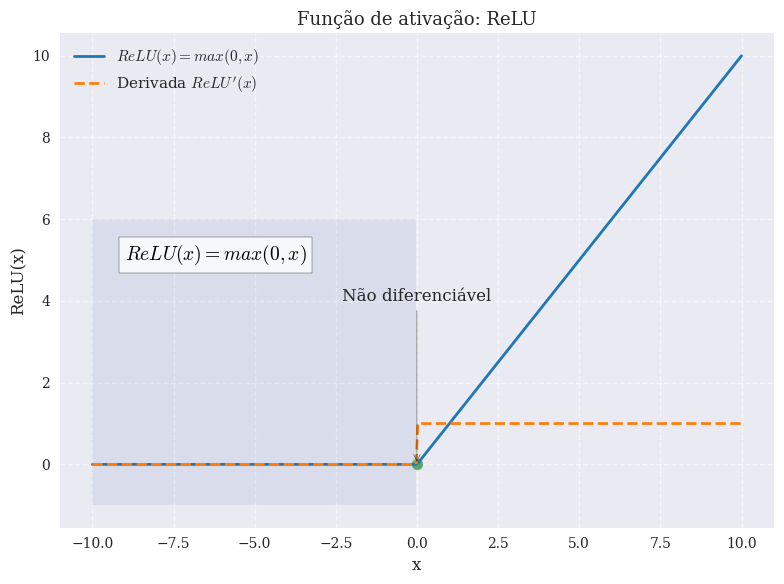

In [ ]:
# Plotando o gráfico da função com sua derivada
def relu_derivative(x):
  """
  Função: relu_derivative
  Descrição: Define a derivada da ReLU: retorna 1 para entradas positivas e 0 para negativas (ou o gradiente sub-gradiente no zero).
  """
  return np.where(x > 0, 1, 0)

x = np.linspace(-10, 10, 400)
y = relu(x)
dy = relu_derivative(x)

plt.style.use('seaborn-v0_8'),
plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "legend.fontsize": 11
})

plt.figure(figsize=(8, 6))
plt.plot(x, y, label="$ReLU(x) = max(0, x)$", color='#1f77b4', linewidth=2)
plt.plot(x, dy, label="Derivada $ReLU'(x)$", color='#ff7f0e', linewidth=2, linestyle='--')
plt.fill_between(x, -1, 6, where=(x < 0), alpha=0.1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.scatter([0], [0], s=60)
plt.annotate("Não diferenciável", (0,0), xytext=(-2.3,4),
             arrowprops=dict(arrowstyle="->"))
plt.text(-9, 5, "$ReLU(x) = max(0, x)$", fontsize=14, color='black', bbox=dict(facecolor='white', alpha=0.8))

plt.title("Função de ativação: ReLU")
plt.xlabel("x")
plt.ylabel("ReLU(x)")
plt.legend()
plt.tight_layout()
plt.savefig('relu.png', bbox_inches='tight')
plt.show()

### Leaky ReLU - Família ReLU

Leaky Rectified Linear Unit (LReLU) é definida pela equação:

$\hspace{5cm} LReLU(x) = max(\alpha x, x)$

E sua derivada é calculada por:

$\hspace{5cm} \frac{dLReLU}{dx} = \begin{cases} 1, \qquad x > 0 \\ \alpha, \qquad x \leq 0\end{cases}$

Essa função de ativação é uma extensão da ReLU utilizando valores negativos. Ela foi desenvolvida para tentar resolver o problema do gradiente e da morte dos neurônios por causa dos valores negativos.

Principal ponto negativo:
- Maior dificuldade é encontrar a melhorar inclinação $\alpha$ para se utilizar.  

Propriedades:
- Não é Paramétrica ($\alpha$ é um valor fixo)
- Monotônica
- Não é suave
- Não é limitada (ao contrário da ReLU): $(-\infty, \infty)$

Referência: https://ai.stanford.edu/~amaas/papers/relu_hybrid_icml2013_final.pdf



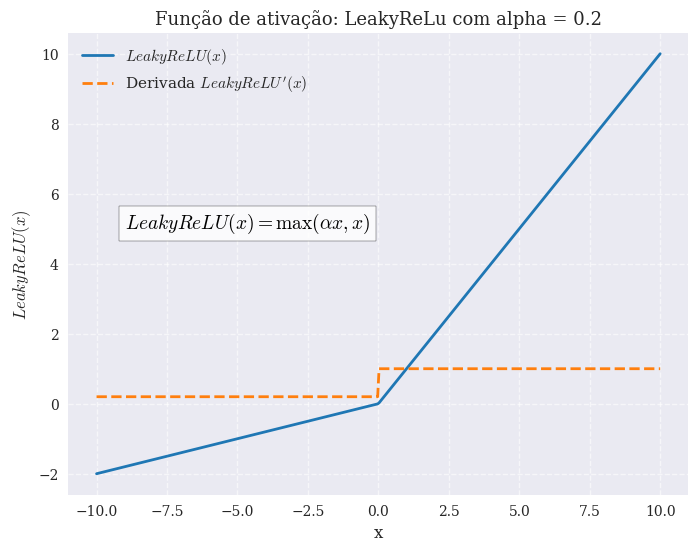

In [ ]:
def leaky_relu_derivative(x, alpha=0.2):
  """
  Função: leaky_relu_derivative
  Descrição: Calcula a derivada da Leaky ReLU, mantendo o coeficiente alpha para valores negativos durante a atualização de pesos.
  """
  return np.where(x > 0, 1, alpha)

x = np.linspace(-10, 10, 400)
y = leaky_relu(x)
dy = leaky_relu_derivative(x)

plt.figure(figsize=(8, 6))
plt.plot(x, y, label="$LeakyReLU(x)$", color='#1f77b4', linewidth=2)
plt.plot(x, dy, label="Derivada $LeakyReLU'(x)$", color='#ff7f0e', linewidth=2, linestyle='--')
plt.grid(True, linestyle='--', alpha=0.6)

plt.text( -9, 5, r"$LeakyReLU(x) = \mathrm{max}(\alpha x, x)$", fontsize=14, color='black', bbox=dict(facecolor='white', alpha=0.8))

plt.title("Função de ativação: LeakyReLu com alpha = 0.2")
plt.xlabel("x")
plt.ylabel("$LeakyReLU(x)$")
plt.legend()
plt.savefig('LeakyReLU.png', bbox_inches='tight')
plt.show()

### ELU - Família ELU

Exponential Linear Unit (ELU) é definida pela equação:

$\hspace{5cm} ELU(x) = \begin{cases} x, & x > 0 \\ \alpha * (e^x - 1), & x \leq 0\end{cases}$

E sua derivada é calculada por:

$\hspace{5cm} \frac{dELU}{dx} = \begin{cases} 1, & x > 0 \\ e^x\alpha, & x \leq 0\end{cases}$

ELU foi construida para lidar com o problema do desaparecimento do gradiente da ReLU (assim como diversas outras funções de ativação) usando a exponencial. No caso da ELU $\alpha$ é um parâmetro aprendido.

Propriedades:
- Paramétrica
- Monotônica
- Suave
- Limitada para valores negativos: $[-1, \infty)$

![image.png](https://figures.semanticscholar.org/d37b3c758faa8a998fd1e76be25a3dbe0c86cca2/6-Table4-1.png)

Referência: https://arxiv.org/abs/1511.07289



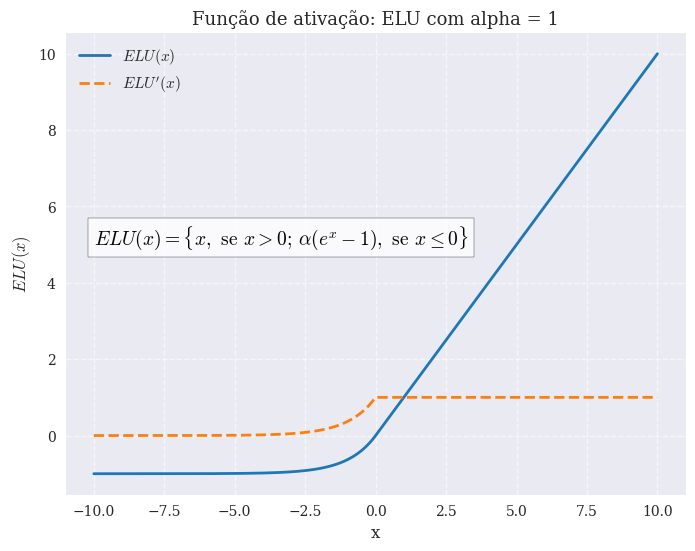

In [ ]:
def elu_derivative(x, alpha=1.0):
  """
  Função: elu_derivative
  Descrição: Implementa a derivada da função ELU, tratando separadamente os casos positivos e a curva exponencial negativa.
  """
  return np.where(x > 0, 1, elu(x, alpha) + alpha)

x = np.linspace(-10, 10, 400)
y = elu(x)
dy = elu_derivative(x)

plt.figure(figsize=(8, 6))
plt.plot(x, y, label="$ELU(x)$", color='#1f77b4', linewidth=2)
plt.plot(x, dy, label="$ELU'(x)$", color='#ff7f0e', linewidth=2, linestyle='--')
plt.grid(True, linestyle='--', alpha=0.6)

plt.text(-10, 5, r"$ELU(x) = \{ x, \text{ se } x > 0 \text{; } \alpha (e^x - 1), \text{ se } x \leq 0 \}$", fontsize=14, color='black', bbox=dict(facecolor='white', alpha=0.8))

plt.title("Função de ativação: ELU com alpha = 1")
plt.xlabel("x")
plt.ylabel("$ELU(x)$")
plt.legend()
plt.savefig('ELU.png', bbox_inches='tight')
plt.show()

### SELU - Família ELU

Scaled ELU (SELU) é definida pela equação:

$\hspace{5cm} SELU(x) = \begin{cases} \lambda x, & x > 0 \\ \lambda \alpha * (e^x - 1), & x \leq 0\end{cases}$

E sua derivada é calculada por:

$\hspace{5cm} \frac{dSELU}{dx} = \begin{cases} \lambda, & x > 0 \\ \lambda e^x\alpha, & x \leq 0\end{cases}$

SELU usa um hiperparâmetro para fazer a inclinação (slope) maior. O que acontece é que para redes inteiramente feitas de camadas densas, a SELU induz uma auto normalização que automaticamente leva a uma média zero e desvio padrão de 1. Isso é feito definindo $\alpha$ e $\lambda$ com valores específicos.

Propriedades:
- Paramétrica
- Monotônica
- Suave
- Limitada para valores negativos: $[-\lambda \alpha, \infty)$

Valor de alpha e lambda: https://docs.pytorch.org/docs/stable/generated/torch.nn.SELU.html

Referência: https://arxiv.org/abs/1706.02515



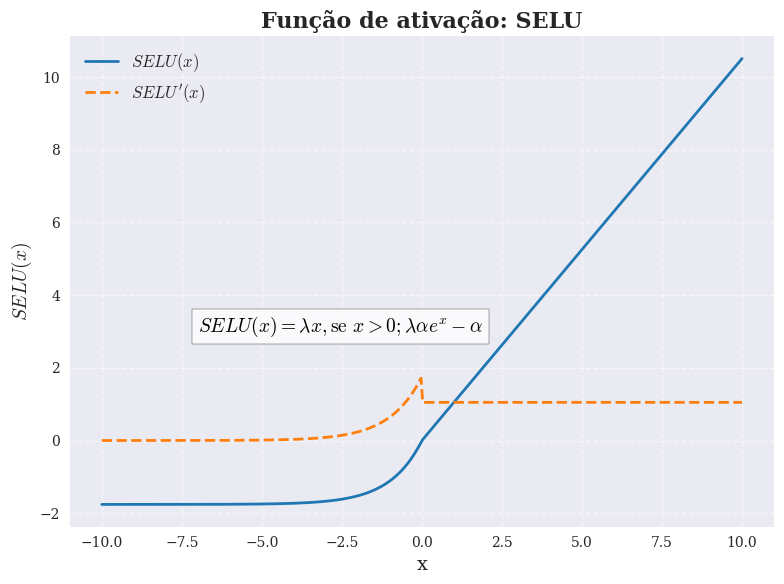

In [ ]:
def selu_derivative(x):
  """
  Função: selu_derivative
  Descrição: Calcula o gradiente da SELU, incorporando os fatores de escala lambda e alpha para garantir a auto-normalização.
  """
  lambda_ = 1.0507
  alpha = 1.67326
  return lambda_ * np.where(x > 0, 1, alpha * np.exp(x))

y_selu = selu(x)
dy_selu = selu_derivative(x)

plt.figure(figsize=(8, 6))
plt.plot(x, y_selu, label="$SELU(x)$", color='#1f77b4', linewidth=2)
plt.plot(x, dy_selu, label="$SELU'(x)$", color='#ff7f0e', linewidth=2, linestyle='--')
plt.grid(True, linestyle='--', alpha=0.6)

plt.text(-7, 3, r"$SELU(x) = \lambda x , \text{se } x > 0; \lambda \alpha e^x - \alpha$", fontsize=14, color='black', bbox=dict(facecolor='white', alpha=0.8))

plt.title("Função de ativação: SELU", fontsize=16, fontweight='bold')
plt.xlabel("x", fontsize=14)
plt.ylabel("$SELU(x)$", fontsize=14)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('SELU.png', dpi=300)
plt.show()

### GELU - Família Probabilistica

Gaussian Error Linear Unit (GELU) é definida como:

$\hspace{5cm} GELU(x) = x * \Phi(x)$

Na qual $\Phi$ é Função de distribuição acumulada da normal. E sua derivada pode ser calculada por:

$0.5 * (1 + tanh(\sqrt{2/\pi} * (x + 0.044715 * x^3))) + 0.5 * x * sech(\sqrt{(2/\pi)} * (x + 0.044715 * x^3))^2 * \sqrt(2/\pi) * (1 + 3 * 0.044715 * x^2)$

É uma função que se tornou estado da arte para modelos baseados em transformers (como BERT,GPT,ViT e outros).

Propriedades:
- Não Paramétrica
- Não Monotônica
- Suave
- Limitada negativamente

Referência: https://arxiv.org/abs/1606.08415


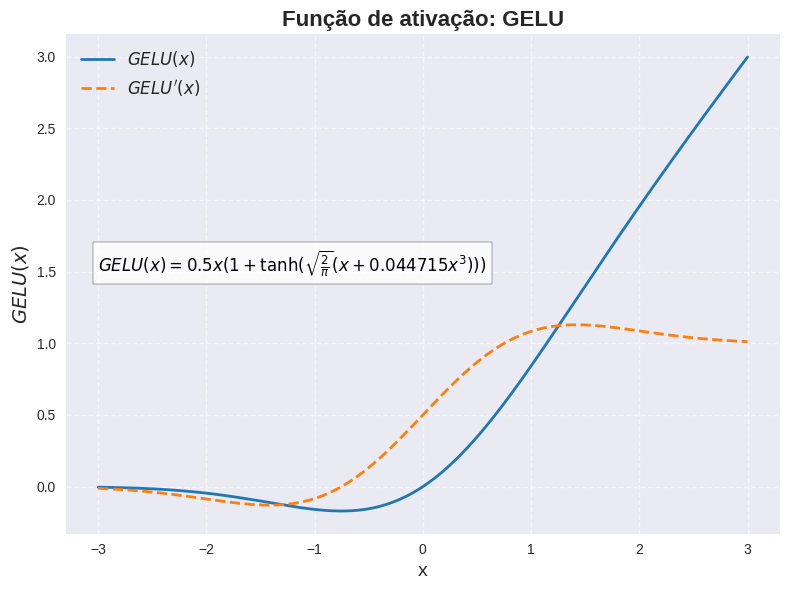

In [ ]:
def gelu_derivative(x):
  """
  Função: gelu_derivative
  Descrição: Aproxima a derivada complexa da função GELU para uso em algoritmos de otimização baseados em gradiente.
  """
  sech = lambda x: 2 / (np.exp(x) + np.exp(-x))
  return 0.5 * (1 + np.tanh(np.sqrt(2/np.pi) * (x + 0.044715 * x**3))) + 0.5 * x * sech(np.sqrt(2/np.pi) * (x + 0.044715 * x**3))**2 * np.sqrt(2/np.pi) * (1 + 3 * 0.044715 * x**2)

x = np.linspace(-3, 3, 400)
y_gelu = gelu(x)
dy_gelu = gelu_derivative(x)

plt.figure(figsize=(8, 6))
plt.plot(x, y_gelu, label="$GELU(x)$", color='#1f77b4', linewidth=2)
plt.plot(x, dy_gelu, label="$GELU'(x)$", color='#ff7f0e', linewidth=2, linestyle='--')
plt.grid(True, linestyle='--', alpha=0.6)

plt.text(-3, 1.5, r"$GELU(x) = 0.5 x (1 + \tanh(\sqrt{\frac{2}{\pi}} (x + 0.044715 x^3)))$", fontsize=12, color='black', bbox=dict(facecolor='white', alpha=0.8))


plt.title("Função de ativação: GELU", fontsize=16, fontweight='bold')
plt.xlabel("x", fontsize=14)
plt.ylabel("$GELU(x)$", fontsize=14)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('GELU.png', dpi=300)
plt.show()

### Swish - Família das Funções Adaptativas

Swish é definida pela equação:

$\hspace{5cm} Swish(x) = x * Sigmoid(\beta x)$

E sua derivada é calculada por:

$\hspace{5cm} \frac{dSwish}{dx} = Sigmoid(\beta x) + x * Sigmoid(\beta x)(1 - Sigmoid(\beta x))$

Maioria das funções de ativação mencionadas até então não são adaptativas, e elas podem não ser capazes de se ajustar a datasets muito complexos. Isso pode ser resolvido com funções de ativação adaptativas. Swish além de não ser limiada, também possui o parâmetro $\beta$ que controla a quantidade de não linearidade da função, ajustando entre valores lineares e a função ReLU.  

Propriedades:
- Paramétrica
- Não Monotônica
- Suave
- Não é limitada

![image.png](https://figures.semanticscholar.org/d37b3c758faa8a998fd1e76be25a3dbe0c86cca2/8-Table5-1.png)

Referência: https://arxiv.org/abs/1710.05941

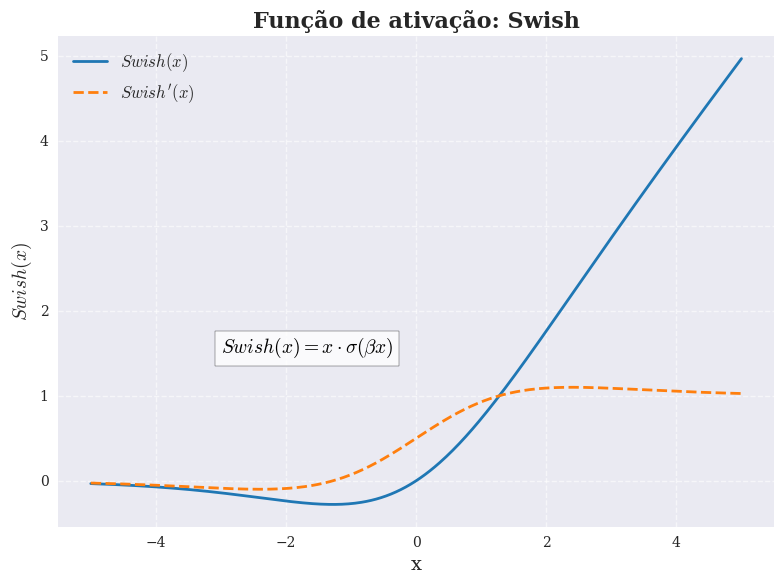

In [ ]:
def swish_derivative(x, beta=1):
  """
  Função: swish_derivative
  Descrição: Calcula a derivada da função Swish, que envolve tanto a função original quanto a sua aplicação sigmoide.
  """
  sigmoid_x = 1 / (1 + np.exp(-beta*x))
  return sigmoid_x + x * sigmoid_x * (1 - sigmoid_x)

y_swish = swish(x, beta=1)
dy_swish = swish_derivative(x, beta=1)

plt.figure(figsize=(8, 6))
plt.plot(x, y_swish, label="$Swish(x)$", color='#1f77b4', linewidth=2)
plt.plot(x, dy_swish, label="$Swish'(x)$", color='#ff7f0e', linewidth=2, linestyle='--')

plt.text(-3, 1.5, r"$Swish(x) = x \cdot \sigma(\beta x)$", fontsize=14, color='black', bbox=dict(facecolor='white', alpha=0.8))

plt.grid(True, linestyle='--', alpha=0.6)
plt.title("Função de ativação: Swish", fontsize=16, fontweight='bold')
plt.xlabel("x", fontsize=14)
plt.ylabel("$Swish(x)$", fontsize=14)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('Swish.png', dpi=300)
plt.show()

### Mish

Swish é definida pela equação:

$\hspace{5cm} Mish(x) = x * tanh(ln(1+e^x))$

E sua derivada é calculada por:

$\hspace{5cm} \frac{dMish}{dx} = tanh(ln(1 + e^x)) + x * sigmoid(x) * (1- tanh^2(ln(1+e^x)))$


Combina propriedades da Swish com a ReLU. Maior problema se deve a grande complexidade computacional de ser calculada

Propriedades:
- Não Paramétrica
- Não Monotônica
- Suave

Referência: https://arxiv.org/abs/1908.08681

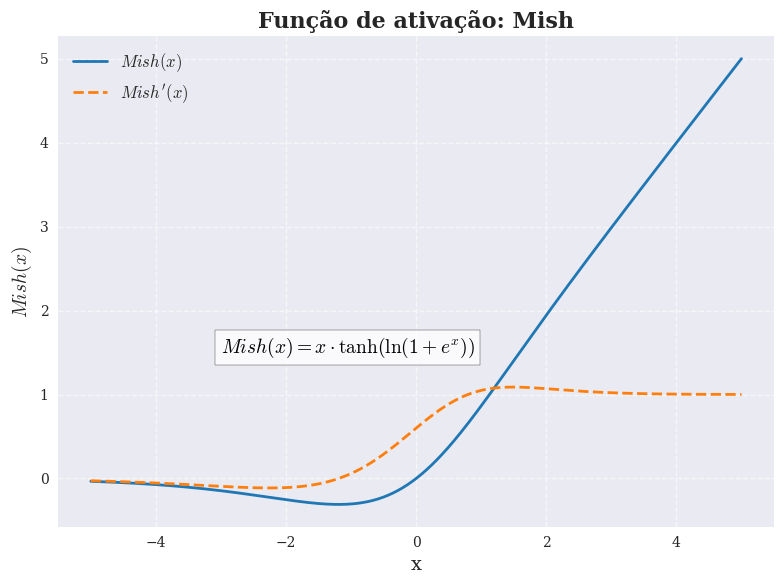

In [ ]:
def mish_derivative(x):
  """
  Função: mish_derivative
  Descrição: Derivada da função Mish, essencial para permitir o treinamento de redes profundas que utilizam esta ativação.
  """
  sigmoid_x = 1 / (1 + np.exp(-x))
  #return np.tanh(np.log(1 + np.exp(x))) + x * (sigmoid_x * (1 - sigmoid_x) * (1 + np.exp(x))**(-1))
  return np.tanh(np.log(1 + np.exp(x))) + x * sigmoid_x * (1-  (tanh(np.log(1 + np.exp(x))))**2)

y_mish = mish(x)
dy_mish = mish_derivative(x)

plt.figure(figsize=(8, 6))
plt.plot(x, y_mish, label="$Mish(x)$",  color='#1f77b4', linewidth=2)
plt.plot(x, dy_mish, label="$Mish'(x)$", color='#ff7f0e', linewidth=2, linestyle='--')
plt.grid(True, linestyle='--', alpha=0.6)

plt.text(-3, 1.5, r"$Mish(x) = x \cdot \tanh(\ln(1 + e^x))$", fontsize=14, color='black', bbox=dict(facecolor='white', alpha=0.8))


plt.title("Função de ativação: Mish", fontsize=16, fontweight='bold')
plt.xlabel("x", fontsize=14)
plt.ylabel("$Mish(x)$", fontsize=14)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('Mish.png', dpi=300)
plt.show()

### GCU, DSU, NCU, SQU e SSU - Família Ocilatória

Growing Cosinet Unit (GCU) foi a primeira função de ativação a trazer funções de ativação oscilatórias, a grande novidade foi que com a GCU era possível resolver o problema XOR com um único neurônio. Pela outras funções de ativação seriam necessários 3 neurônios. Além disso, apresentanm propriedades interessantes (ex: ajuda contra o desaparecimento do gradiente) e é mais simples de computar que funções como mish.

As outras funções, foram apresentadas pelo mesmo autor, que também permitem resolver o XOR com um único neurônio, mas suas propriedades não foram ainda exploradas:
- Non-Monotonic Cubic Unit (NCU)
- Shifted Quadratic Unit (SQU)
- Decaying Sine Unit (DSU)
- Shifted Sinc Unit (SSU)

Referências:

GCU - https://arxiv.org/abs/2108.12943

Outras - https://arxiv.org/abs/2204.02921

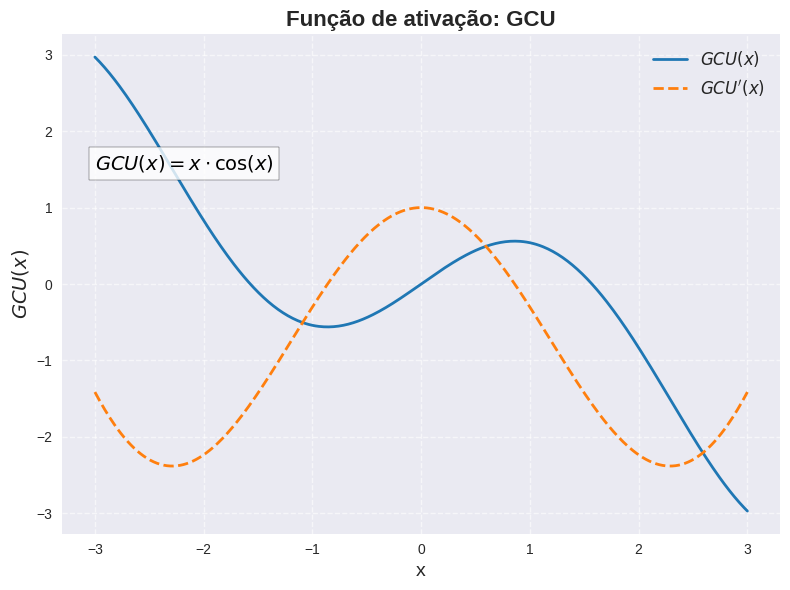

In [ ]:
def GCU_derivative(x):
  """
  Função: GCU_derivative
  Descrição: Derivada da Growing Cosine Unit, baseada em funções trigonométricas.
  """
  return np.cos(x) - x*np.sin(x)

y_GCU = GCU(x)
dy_GCU= GCU_derivative(x)

plt.figure(figsize=(8, 6))
plt.plot(x, y_GCU, label="$GCU(x)$",  color='#1f77b4', linewidth=2)
plt.plot(x, dy_GCU, label="$GCU'(x)$", color='#ff7f0e', linewidth=2, linestyle='--')
plt.grid(True, linestyle='--', alpha=0.6)

plt.text(-3, 1.5, r"$GCU(x) = x \cdot \cos(x)$", fontsize=14, color='black', bbox=dict(facecolor='white', alpha=0.8))


plt.title("Função de ativação: GCU", fontsize=16, fontweight='bold')
plt.xlabel("x", fontsize=14)
plt.ylabel("$GCU(x)$", fontsize=14)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('GCU.png', dpi=300)
plt.show()

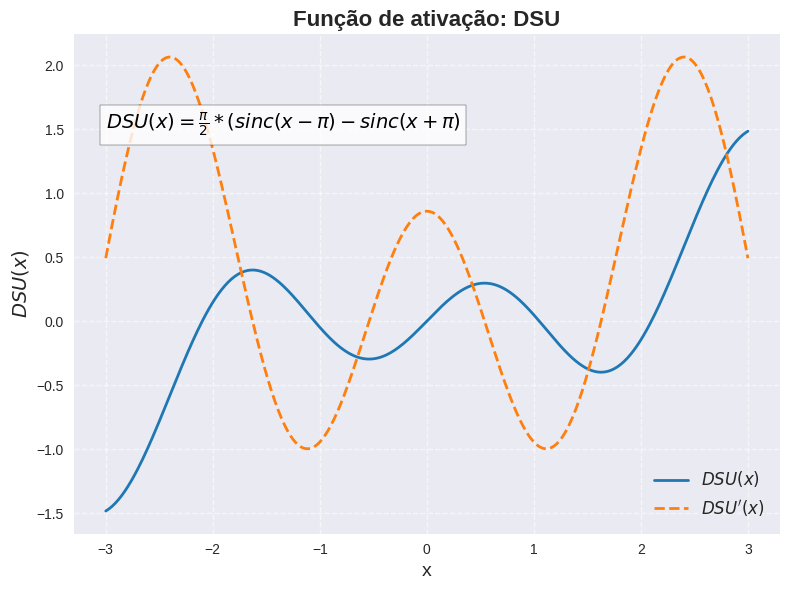

In [ ]:
def DSU_derivative(x):
  """
  Função: DSU_derivative
  Descrição: Gradiente da Decaying Sine Unit, usado no backpropagation.
"""
  numerador_1 = np.pi*np.cos(np.pi*(x - np.pi))*(x-np.pi) - np.sin(np.pi*(x - np.pi))
  denominador_1 = 2*((x-np.pi)**2)
  numerador_2 = np.pi*np.cos(np.pi*(x + np.pi))*(x+np.pi) - np.sin(np.pi*(x + np.pi))
  denominador_2 = 2*((x+np.pi)**2)
  return (numerador_1/denominador_1) - (numerador_2/denominador_2)

y_DSU = DSU(x)
dy_DSU= DSU_derivative(x)

plt.figure(figsize=(8, 6))
plt.plot(x, y_DSU, label="$DSU(x)$",  color='#1f77b4', linewidth=2)
plt.plot(x, dy_DSU, label="$DSU'(x)$", color='#ff7f0e', linewidth=2, linestyle='--')
plt.grid(True, linestyle='--', alpha=0.6)

plt.text(-3, 1.5, r"$DSU(x) = \frac{\pi}{2}*(sinc(x - \pi) - sinc(x + \pi) $",
         fontsize=14, color='black', bbox=dict(facecolor='white', alpha=0.8))


plt.title("Função de ativação: DSU", fontsize=16, fontweight='bold')
plt.xlabel("x", fontsize=14)
plt.ylabel("$DSU(x)$", fontsize=14)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('DSU.png', dpi=300)
plt.show()

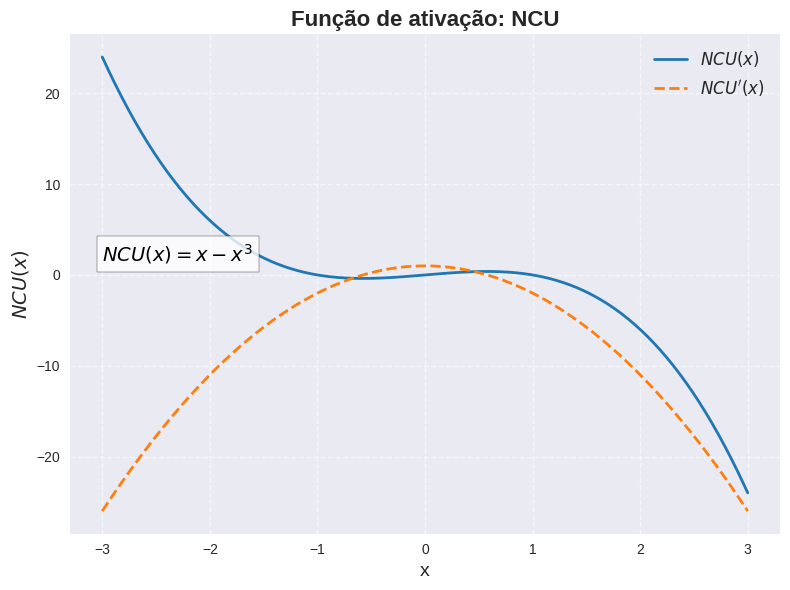

In [ ]:
def NCU_derivative(x):
  """
  Função: NCU_derivative
  Descrição: Derivada da função cúbica NCU.
  """
  return 1 - 3*(x**2)

y_NCU = NCU(x)
dy_NCU= NCU_derivative(x)

plt.figure(figsize=(8, 6))
plt.plot(x, y_NCU, label="$NCU(x)$",  color='#1f77b4', linewidth=2)
plt.plot(x, dy_NCU, label="$NCU'(x)$", color='#ff7f0e', linewidth=2, linestyle='--')
plt.grid(True, linestyle='--', alpha=0.6)

plt.text(-3, 1.5, r"$NCU(x) = x - x^3$", fontsize=14, color='black', bbox=dict(facecolor='white', alpha=0.8))


plt.title("Função de ativação: NCU", fontsize=16, fontweight='bold')
plt.xlabel("x", fontsize=14)
plt.ylabel("$NCU(x)$", fontsize=14)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('NCU.png', dpi=300)
plt.show()

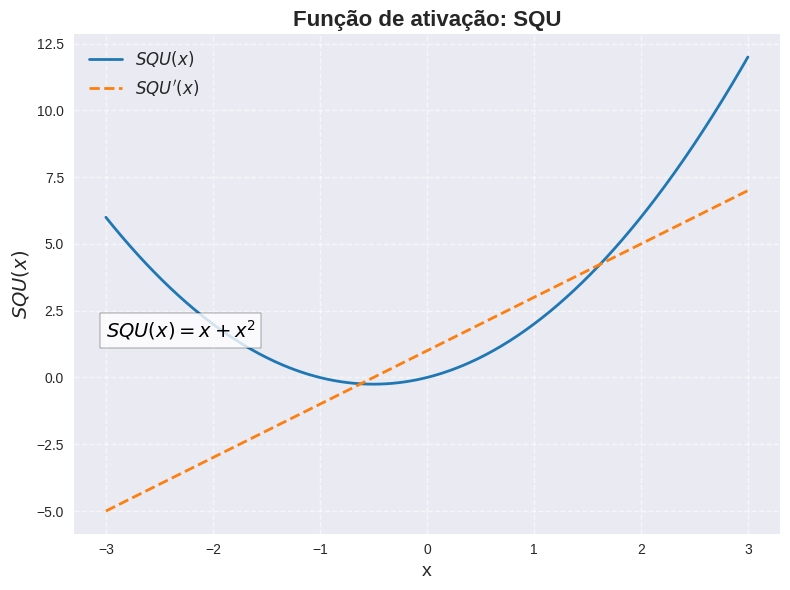

In [ ]:
def SQU_derivative(x):
  """
  Função: SQU_derivative
  Descrição: Derivada da função quadrática SQU.
  """
  return 2*x + 1

y_SQU = SQU(x)
dy_SQU= SQU_derivative(x)

plt.figure(figsize=(8, 6))
plt.plot(x, y_SQU, label="$SQU(x)$",  color='#1f77b4', linewidth=2)
plt.plot(x, dy_SQU, label="$SQU'(x)$", color='#ff7f0e', linewidth=2, linestyle='--')
plt.grid(True, linestyle='--', alpha=0.6)

plt.text(-3, 1.5, r"$SQU(x) = x + x^2$", fontsize=14, color='black', bbox=dict(facecolor='white', alpha=0.8))


plt.title("Função de ativação: SQU", fontsize=16, fontweight='bold')
plt.xlabel("x", fontsize=14)
plt.ylabel("$SQU(x)$", fontsize=14)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('SQU.png', dpi=300)
plt.show()

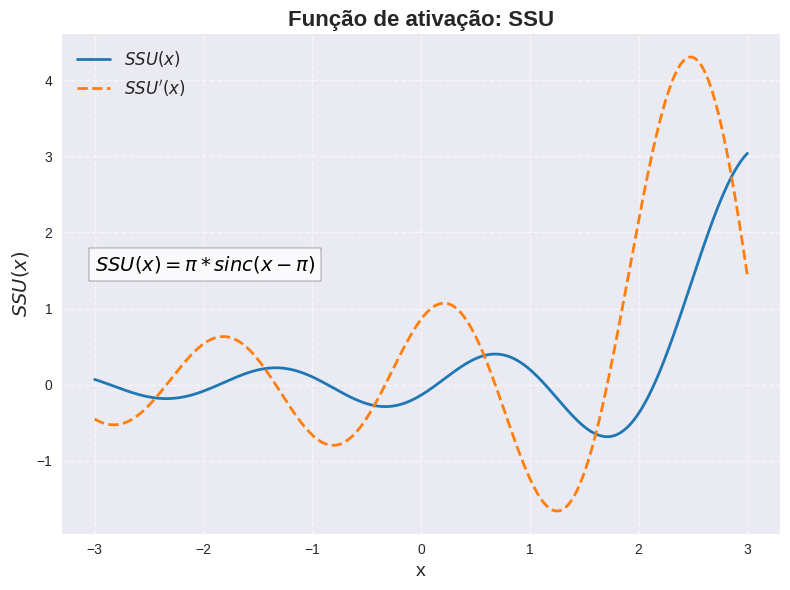

In [ ]:
def SSU_derivative(x):
  """
  Função: SSU_derivative
  Descrição: Derivada da função Sinc deslocada.
  """
  numerador = np.pi*np.cos(np.pi*(x - np.pi))*(x-np.pi) - np.sin(np.pi*(x - np.pi))
  denominador = (x-np.pi)**2
  return numerador/denominador


y_SSU = SSU(x)
dy_SSU= SSU_derivative(x)

plt.figure(figsize=(8, 6))
plt.plot(x, y_SSU, label="$SSU(x)$",  color='#1f77b4', linewidth=2)
plt.plot(x, dy_SSU, label="$SSU'(x)$", color='#ff7f0e', linewidth=2, linestyle='--')
plt.grid(True, linestyle='--', alpha=0.6)

plt.text(-3, 1.5, r"$SSU(x) = \pi * sinc(x- \pi)$", fontsize=14, color='black', bbox=dict(facecolor='white', alpha=0.8))


plt.title("Função de ativação: SSU", fontsize=16, fontweight='bold')
plt.xlabel("x", fontsize=14)
plt.ylabel("$SSU(x)$", fontsize=14)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('SSU.png', dpi=300)
plt.show()

### APALU - Família Adaptativa

Adaptive piecewise approximated activation linear unit (APALU), é uma função aprendida, definida por:

$\hspace{5cm} APALU(x) = \begin{cases} a(x + x(\frac{1}{1 + e^{-1.702(x)}})), & x \geq 0 \\ b(e^x - 1), & x < 0\end{cases}$

E sua derivada é calculada por:

$\hspace{5cm} \frac{dAPALU}{dx} = \begin{cases} a*(1 + (1/(1 + np.exp(-1.702*x))) + ((1.702*np.exp(-1.702*x)*x)/((1 + np.exp(-1.702*x))**2))) & x \geq 0 \\ be^x,  & x < 0\end{cases}$

Principais pontos da APLU é manter a estabilidade e eficiência enquanto se adapta a dados e representações complexas.

Referência: https://arxiv.org/pdf/2402.08244

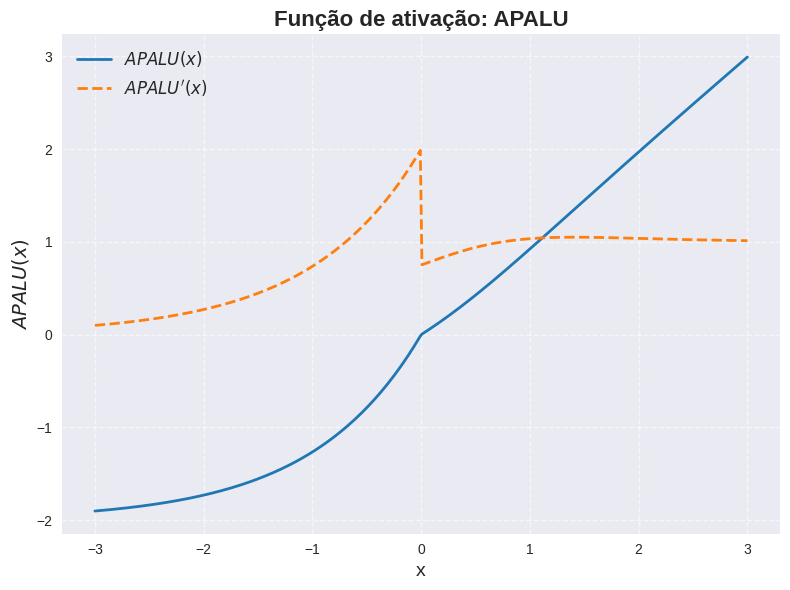

In [ ]:
def APALU_derivative(x, a=0.5, b=2):
  """
  Função: APALU_derivative
  Descrição: Derivada da função adaptativa APALU.
  """
  return np.where(x >= 0, a*(1 + (1/(1 + np.exp(-1.702*x))) + ((1.702*np.exp(-1.702*x)*x)/((1 + np.exp(-1.702*x))**2))), b*np.exp(x))

y_APALU = APALU(x)
dy_APALU= APALU_derivative(x)

plt.figure(figsize=(8, 6))
plt.plot(x, y_APALU, label="$APALU(x)$",  color='#1f77b4', linewidth=2)
plt.plot(x, dy_APALU, label="$APALU'(x)$", color='#ff7f0e', linewidth=2, linestyle='--')
plt.grid(True, linestyle='--', alpha=0.6)

plt.title("Função de ativação: APALU", fontsize=16, fontweight='bold')
plt.xlabel("x", fontsize=14)
plt.ylabel("$APALU(x)$", fontsize=14)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('APALU.png', dpi=300)
plt.show()